In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

df = pd.read_csv("/Users/evelyn/Documents/claudecode/speechlab/week-07/neurovoz_free_egemaps_summary.csv")
df.head()

,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
0,'HC_FREE_0120.wav',0.0,30.11075,0.177768,27.79075,30.85764,34.02055,6.229801,278.8759,338.9022,...,-0.005359,0.035927,2.587290,1.483904,0.362203,0.446914,0.292373,0.493123,-42.14192,0
1,'HC_FREE_0134.wav',0.0,26.78071,0.204064,23.71242,27.29546,31.14834,7.435919,190.1509,257.4780,...,-0.006157,0.136789,3.952802,2.263780,0.270000,0.209397,0.151403,0.179169,-29.02919,0
2,'HC_FREE_0068.wav',0.0,27.61204,0.238656,23.73901,28.83757,31.82466,8.085651,296.6854,333.7662,...,-0.009552,0.099828,3.971813,2.382486,0.231351,0.232764,0.160526,0.210362,-34.72137,0
3,'HC_FREE_0054.wav',0.0,28.91502,0.127654,27.48843,29.13435,31.29628,3.807844,157.0168,135.1087,...,-0.004518,0.072883,2.955301,1.776462,0.340417,0.232424,0.197347,0.291546,-34.37103,0
4,'HC_FREE_0083.wav',0.0,24.51973,0.146187,23.31608,25.01538,26.40105,3.084976,351.7924,404.7467,...,-0.005311,0.155983,3.038674,2.016608,0.308627,0.315812,0.176667,0.207548,-32.28918,0


In [10]:
print(f"Shape: (rows = {df.shape[0]} audio files, cols = {df.shape[1]} features [88 eGeMAPS + name + frameTime + label])")
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (rows = 76 audio files, cols = 91 features [88 eGeMAPS + name + frameTime + label])

Class distribution:
label
0    53
1    23
Name: count, dtype: int64

Missing values: 0


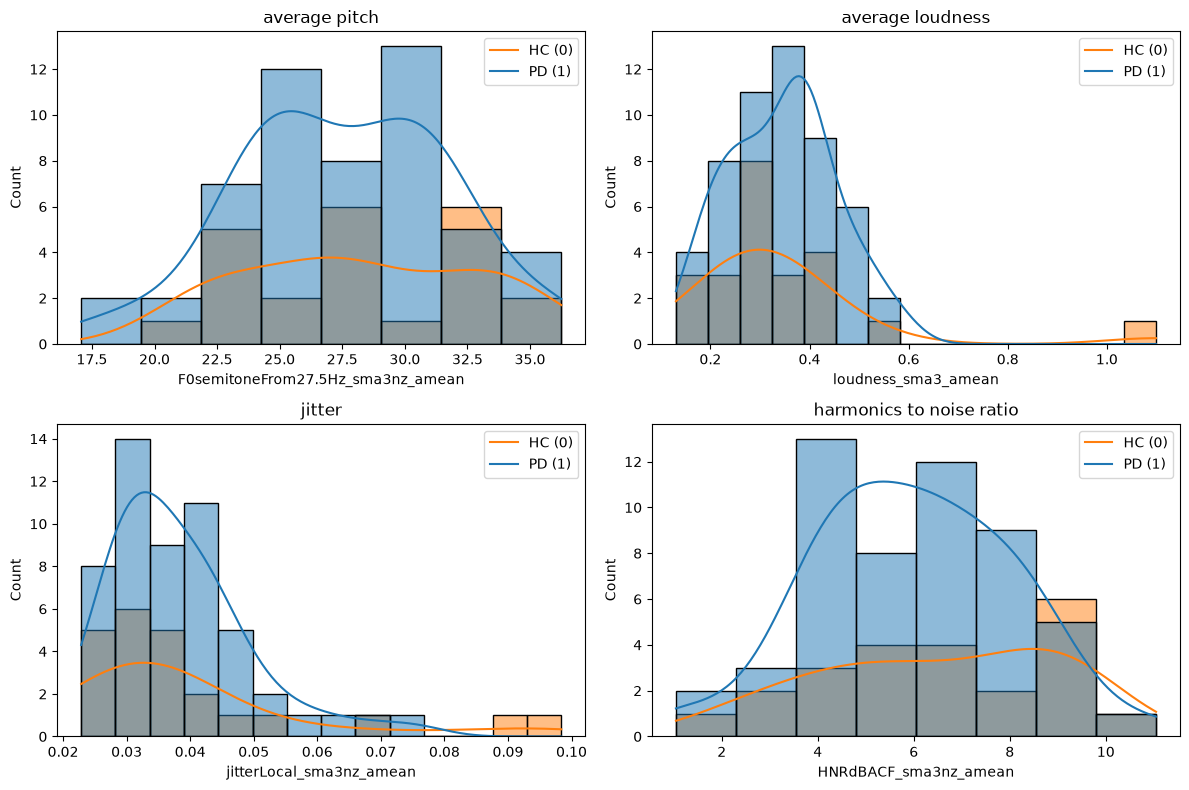

In [11]:
features_to_plot = {
    "F0semitoneFrom27.5Hz_sma3nz_amean": "average pitch",
    "loudness_sma3_amean": "average loudness",
    "jitterLocal_sma3nz_amean": "jitter",
    "HNRdBACF_sma3nz_amean": "harmonics to noise ratio",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (feature, description) in enumerate(features_to_plot.items()):
    sns.histplot(data=df, x=feature, hue="label", ax=axes[i], kde=True)
    axes[i].set_title(description)
    axes[i].legend(["HC (0)", "PD (1)"])

plt.tight_layout()
plt.show()

**Expected vs actual:**
- Pitch: expect PD more monotone/lower — actual: means nearly identical (HC 27.6 vs PD 28.2)
- Loudness: expect PD quieter (hypophonia) — actual: means nearly identical (HC 0.345 vs PD 0.342)
- Jitter: expect PD higher (irregular vocal fold vibration) — actual: PD slightly higher (0.0405 vs 0.0383), small gap
- HNR: expect PD lower (noisier voice) — actual: PD is *higher* on average (6.49 vs 5.96), opposite of expectation

**Why the histograms look so overlapped:** we only have 76 recordings total (53 HC, 23 PD), so each histogram/KDE is built from a small, sparse sample. With that few points per group, the distributions naturally look noisy and heavily overlapping — this is a sample-size issue, not proof that these features carry no signal.

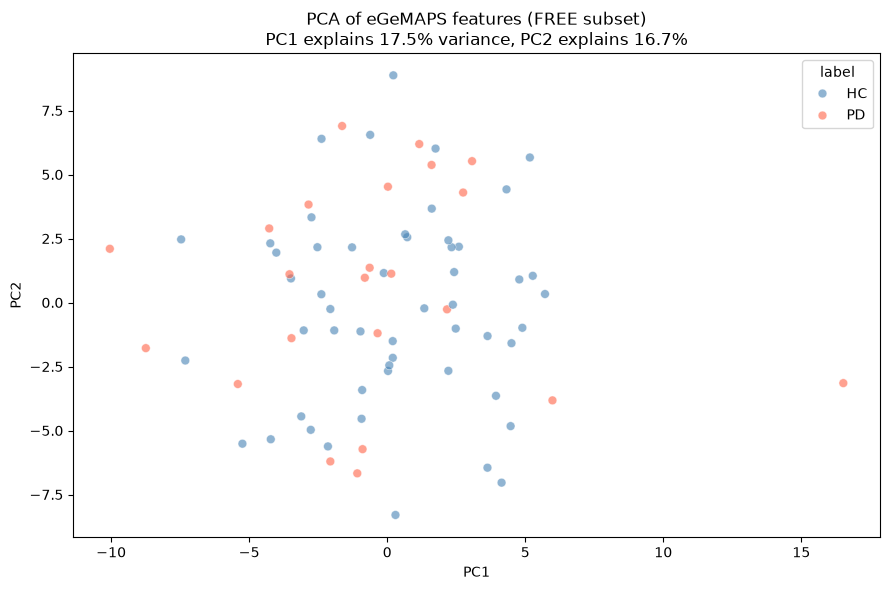

In [12]:
feature_cols = [c for c in df.columns if c not in ("name", "frameTime", "label")]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": df["label"].map({0: "HC", 1: "PD"}),
})

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="label", alpha=0.6, s=40,
    palette={"HC": "steelblue", "PD": "tomato"},
    ax=ax,
)
ax.set_title(
    f"PCA of eGeMAPS features (FREE subset)\n"
    f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% variance, "
    f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}%"
)
plt.tight_layout()
plt.show()

**Expected vs actual:** with a strong acoustic signal, we'd expect PC1/PC2 to separate into two visible clusters. Actual: PC1 + PC2 only explain ~34% of total variance (17.5% + 16.7%) and the HC/PD points are heavily intermixed with no visible boundary. This tracks with the dataset shape — 88 features but only 76 samples (23 PD) — which is exactly the kind of wide, sparse setup where a 2D PCA projection rarely shows clean separation, even if some individual features (or non-linear combinations, which PCA can't capture) still carry signal.

In [13]:
X = df[feature_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test), target_names=["HC", "PD"]))

              precision    recall  f1-score   support

          HC       0.85      1.00      0.92        11
          PD       1.00      0.60      0.75         5

    accuracy                           0.88        16
   macro avg       0.92      0.80      0.83        16
weighted avg       0.89      0.88      0.86        16



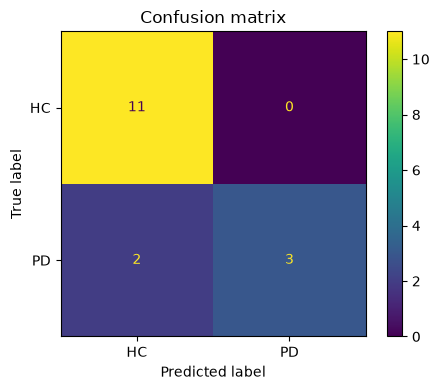

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test),
    display_labels=["HC", "PD"],
    ax=ax,
)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

**Expected vs actual:** overall accuracy is 0.88, but the two classes behave very differently — PD precision is 1.00 (every "PD" prediction was correct) while PD recall is only 0.60 (it missed 2 of 5 actual PD cases in the test set, per the confusion matrix). That asymmetry means the model is conservative about calling PD rather than confidently distinguishing the groups. With only 16 test files (5 PD), each misclassified file swings the metrics by ~10-20 points, so treat these numbers as a rough signal rather than a robust performance estimate — a proper estimate would need cross-validation or a larger PD sample.

In [15]:
# human-readable names for all 88 eGeMAPS features
readable = {
    # Pitch (F0)
    "F0semitoneFrom27.5Hz_sma3nz_amean":            "Pitch — mean",
    "F0semitoneFrom27.5Hz_sma3nz_stddevNorm":       "Pitch — variation",
    "F0semitoneFrom27.5Hz_sma3nz_percentile20.0":   "Pitch — 20th percentile",
    "F0semitoneFrom27.5Hz_sma3nz_percentile50.0":   "Pitch — median",
    "F0semitoneFrom27.5Hz_sma3nz_percentile80.0":   "Pitch — 80th percentile",
    "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2":     "Pitch — range (20th–80th)",
    "F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope":  "Pitch — rising slope (mean)",
    "F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope":"Pitch — rising slope (variation)",
    "F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope": "Pitch — falling slope (mean)",
    "F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope":"Pitch — falling slope (variation)",
    # Jitter (cycle-to-cycle pitch irregularity)
    "jitterLocal_sma3nz_amean":                     "Jitter — mean",
    "jitterLocal_sma3nz_stddevNorm":                "Jitter — variation",
    # Shimmer (cycle-to-cycle amplitude irregularity)
    "shimmerLocaldB_sma3nz_amean":                  "Shimmer — mean",
    "shimmerLocaldB_sma3nz_stddevNorm":             "Shimmer — variation",
    # Harmonics-to-Noise Ratio
    "HNRdBACF_sma3nz_amean":                        "HNR — mean",
    "HNRdBACF_sma3nz_stddevNorm":                   "HNR — variation",
    # H1-H2 log ratio (breathiness — incomplete glottal closure)
    "logRelF0-H1-H2_sma3nz_amean":                 "H1–H2 log ratio (breathiness) — mean",
    "logRelF0-H1-H2_sma3nz_stddevNorm":            "H1–H2 log ratio (breathiness) — variation",
    # H1-A3 log ratio (voice quality — strength of 3rd formant relative to H1)
    "logRelF0-H1-A3_sma3nz_amean":                 "H1–A3 log ratio (voice quality) — mean",
    "logRelF0-H1-A3_sma3nz_stddevNorm":            "H1–A3 log ratio (voice quality) — variation",
    # Loudness
    "loudness_sma3_amean":                          "Loudness — mean",
    "loudness_sma3_stddevNorm":                     "Loudness — variation",
    "loudness_sma3_percentile20.0":                 "Loudness — 20th percentile",
    "loudness_sma3_percentile50.0":                 "Loudness — median",
    "loudness_sma3_percentile80.0":                 "Loudness — 80th percentile",
    "loudness_sma3_pctlrange0-2":                   "Loudness — range (20th–80th)",
    "loudness_sma3_meanRisingSlope":                "Loudness — rising slope (mean)",
    "loudness_sma3_stddevRisingSlope":              "Loudness — rising slope (variation)",
    "loudness_sma3_meanFallingSlope":               "Loudness — falling slope (mean)",
    "loudness_sma3_stddevFallingSlope":             "Loudness — falling slope (variation)",
    # MFCCs (vocal tract shape) — all frames and voiced-only
    "mfcc1_sma3_amean":                             "MFCC 1 — mean",
    "mfcc1_sma3_stddevNorm":                        "MFCC 1 — variation",
    "mfcc2_sma3_amean":                             "MFCC 2 — mean",
    "mfcc2_sma3_stddevNorm":                        "MFCC 2 — variation",
    "mfcc3_sma3_amean":                             "MFCC 3 — mean",
    "mfcc3_sma3_stddevNorm":                         "MFCC 3 — variation",
    "mfcc4_sma3_amean":                             "MFCC 4 — mean",
    "mfcc4_sma3_stddevNorm":                        "MFCC 4 — variation",
    "mfcc1V_sma3nz_amean":                          "MFCC 1 voiced — mean",
    "mfcc1V_sma3nz_stddevNorm":                     "MFCC 1 voiced — variation",
    "mfcc2V_sma3nz_amean":                          "MFCC 2 voiced — mean",
    "mfcc2V_sma3nz_stddevNorm":                     "MFCC 2 voiced — variation",
    "mfcc3V_sma3nz_amean":                          "MFCC 3 voiced — mean",
    "mfcc3V_sma3nz_stddevNorm":                     "MFCC 3 voiced — variation",
    "mfcc4V_sma3nz_amean":                          "MFCC 4 voiced — mean",
    "mfcc4V_sma3nz_stddevNorm":                     "MFCC 4 voiced — variation",
    # Formants (resonance frequencies of the vocal tract)
    "F1frequency_sma3nz_amean":                     "Formant 1 freq — mean",
    "F1frequency_sma3nz_stddevNorm":                "Formant 1 freq — variation",
    "F1bandwidth_sma3nz_amean":                     "Formant 1 bandwidth — mean",
    "F1bandwidth_sma3nz_stddevNorm":                "Formant 1 bandwidth — variation",
    "F1amplitudeLogRelF0_sma3nz_amean":             "Formant 1 amplitude rel. pitch — mean",
    "F1amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 1 amplitude rel. pitch — variation",
    "F2frequency_sma3nz_amean":                     "Formant 2 freq — mean",
    "F2frequency_sma3nz_stddevNorm":                "Formant 2 freq — variation",
    "F2bandwidth_sma3nz_amean":                     "Formant 2 bandwidth — mean",
    "F2bandwidth_sma3nz_stddevNorm":                "Formant 2 bandwidth — variation",
    "F2amplitudeLogRelF0_sma3nz_amean":             "Formant 2 amplitude rel. pitch — mean",
    "F2amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 2 amplitude rel. pitch — variation",
    "F3frequency_sma3nz_amean":                     "Formant 3 freq — mean",
    "F3frequency_sma3nz_stddevNorm":                "Formant 3 freq — variation",
    "F3bandwidth_sma3nz_amean":                     "Formant 3 bandwidth — mean",
    "F3bandwidth_sma3nz_stddevNorm":                "Formant 3 bandwidth — variation",
    "F3amplitudeLogRelF0_sma3nz_amean":             "Formant 3 amplitude rel. pitch — mean",
    "F3amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 3 amplitude rel. pitch — variation",
    # Spectral shape — voiced segments
    "alphaRatioV_sma3nz_amean":                     "Alpha ratio voiced — mean",
    "alphaRatioV_sma3nz_stddevNorm":                "Alpha ratio voiced — variation",
    "hammarbergIndexV_sma3nz_amean":                "Hammarberg index voiced — mean",
    "hammarbergIndexV_sma3nz_stddevNorm":           "Hammarberg index voiced — variation",
    "slopeV0-500_sma3nz_amean":                     "Spectral slope 0–500 Hz voiced — mean",
    "slopeV0-500_sma3nz_stddevNorm":                "Spectral slope 0–500 Hz voiced — variation",
    "slopeV500-1500_sma3nz_amean":                  "Spectral slope 500–1500 Hz voiced — mean",
    "slopeV500-1500_sma3nz_stddevNorm":             "Spectral slope 500–1500 Hz voiced — variation",
    "spectralFluxV_sma3nz_amean":                   "Spectral flux voiced — mean",
    "spectralFluxV_sma3nz_stddevNorm":              "Spectral flux voiced — variation",
    # Spectral shape — all frames
    "spectralFlux_sma3_amean":                      "Spectral flux — mean",
    "spectralFlux_sma3_stddevNorm":                 "Spectral flux — variation",
    # Spectral shape — unvoiced segments
    "alphaRatioUV_sma3nz_amean":                    "Alpha ratio unvoiced — mean",
    "hammarbergIndexUV_sma3nz_amean":               "Hammarberg index unvoiced — mean",
    "slopeUV0-500_sma3nz_amean":                    "Spectral slope 0–500 Hz unvoiced — mean",
    "slopeUV500-1500_sma3nz_amean":                 "Spectral slope 500–1500 Hz unvoiced — mean",
    "spectralFluxUV_sma3nz_amean":                  "Spectral flux unvoiced — mean",
    # High-level descriptors
    "loudnessPeaksPerSec":                          "Loudness peaks per second",
    "VoicedSegmentsPerSec":                         "Voiced segments per second",
    "MeanVoicedSegmentLengthSec":                   "Mean voiced segment length (s)",
    "StddevVoicedSegmentLengthSec":                 "Voiced segment length — variation (s)",
    "MeanUnvoicedSegmentLength":                    "Mean unvoiced segment length (s)",
    "StddevUnvoicedSegmentLength":                  "Unvoiced segment length — variation (s)",
    "equivalentSoundLevel_dBp":                     "Equivalent sound level (dB)",
}

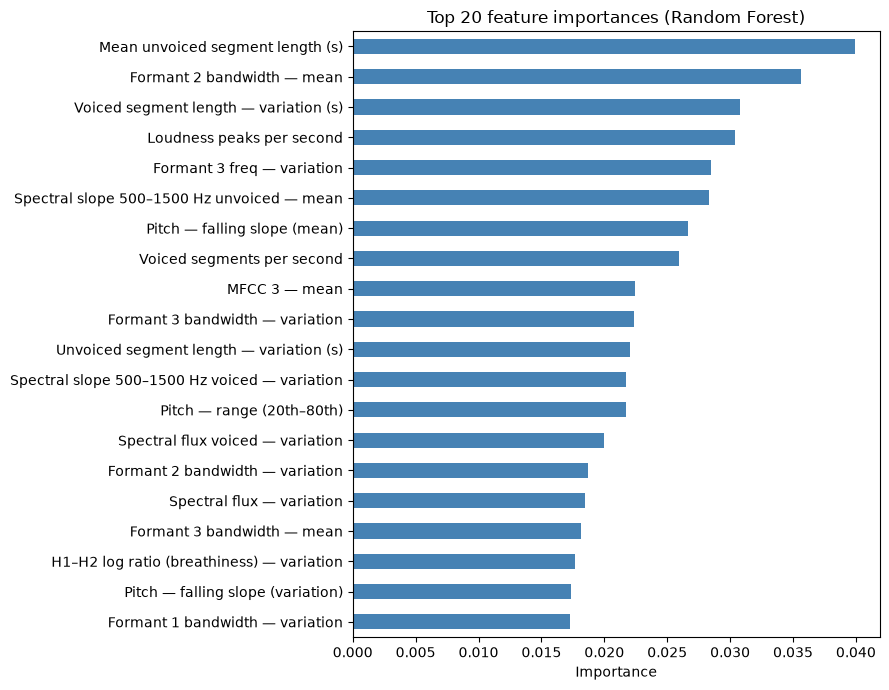

In [16]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()
top20_readable = top20.copy()
top20_readable.index = [readable.get(f, f) for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
top20_readable.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 feature importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Expected vs actual:** clinically, PD voice studies usually lead with jitter, shimmer, HNR, and pitch variability — the classic "voice quality" markers we plotted in Step 3. Actual: the top of this ranking is dominated by pause/segment-timing features (unvoiced segment length and its variation, voiced segments per second, loudness peaks per second) and formant bandwidth/frequency variation (F2, F3), not jitter/shimmer/HNR. This lines up with PD's known effect on speech *rate and rhythm* — slower, more effortful spontaneous speech with irregular pausing — which may show up more strongly in free monologue than in the sustained-vowel or read-sentence tasks where jitter/shimmer/HNR are typically the strongest markers. With only 23 PD samples driving this ranking, treat it as a rough signal rather than a settled biomarker list.

**Why loudness isn't a top feature here (unlike TORGO):** in the TORGO dysarthria analysis, raw loudness (especially the 20th percentile, the "quiet-moment floor") was the #1 feature by a wide margin. Here, none of the raw amplitude-based loudness features (`loudness_sma3_amean`, `_percentile20`, `equivalentSoundLevel_dBp`, etc.) crack the top 20 — they rank in the 24th–87th range out of 88. Only `loudnessPeaksPerSec` (a rate/rhythm feature — how often loudness peaks occur, not how loud they are) makes the top 4. The group means make this concrete: mean loudness is 0.345 (HC) vs 0.342 (PD), and equivalent sound level is -34.98 dB (HC) vs -35.03 dB (PD) — essentially identical, with PD actually showing *higher* variance, not a lower amplitude floor.

Note: PD itself does cause dysarthria — specifically **hypokinetic dysarthria** — so this isn't "dysarthria vs. no dysarthria." TORGO's dysarthric speakers have it from cerebral palsy and ALS, which produce different subtypes (spastic/ataxic for CP, mixed spastic-flaccid for ALS), often involving more severe respiratory/laryngeal muscle weakness than PD typically does, especially at earlier disease stages — that's the more likely driver of TORGO's much stronger loudness signal, rather than PD lacking a loudness effect altogether. Other likely contributors here: (1) if neurovoz recordings were level-normalized or captured at a fixed mic distance in a clinical booth, that would flatten out genuine between-speaker loudness differences that could otherwise carry disease signal; (2) with only 23 PD recordings, everyday speaking-volume variation (personality, room, mic placement) likely swamps any subtler PD-related loudness effect, whereas timing/pause features apparently survived that noise better.

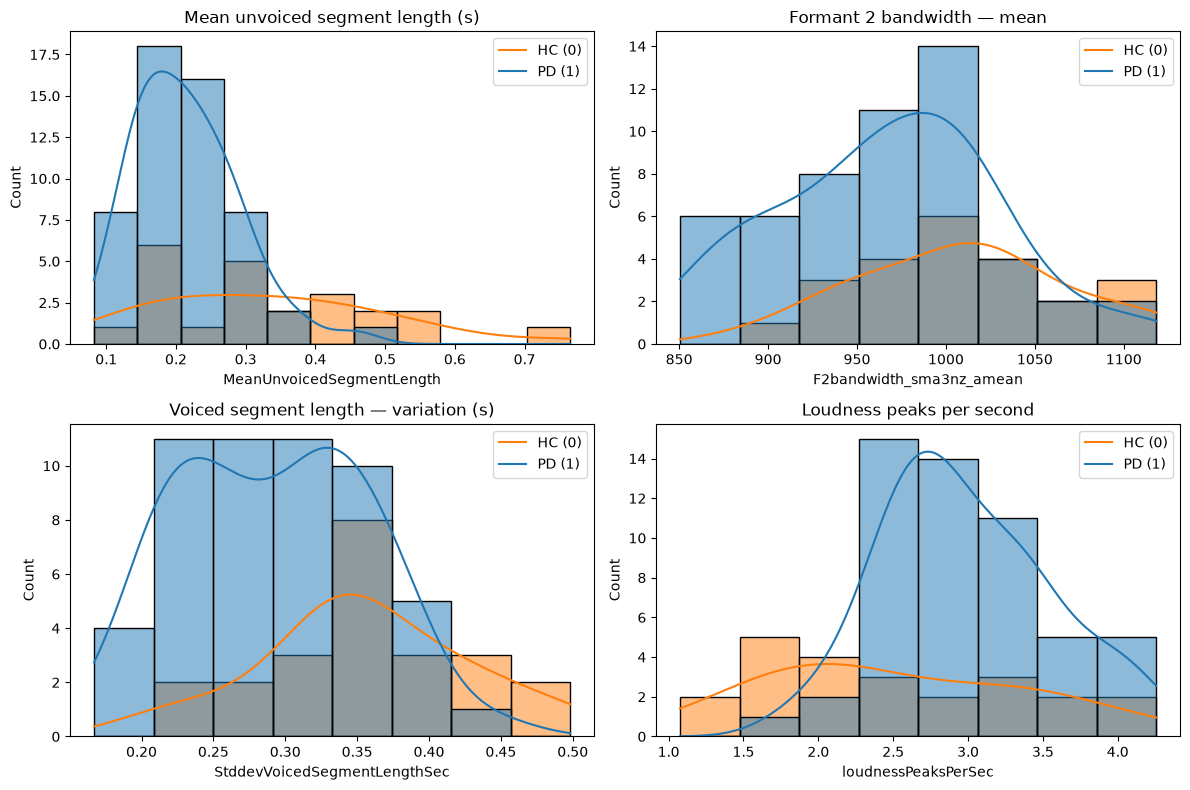

In [17]:
top4 = importances.nlargest(4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top4.index):
    sns.histplot(data=df, x=feature, hue="label", ax=axes[i], kde=True)
    axes[i].set_title(readable.get(feature, feature))
    axes[i].legend(["HC (0)", "PD (1)"])

plt.tight_layout()
plt.show()

**Expected vs actual:** since these are the Random Forest's top 4 features by importance, we'd expect them to show the widest HC/PD separation of any features in the dataset — that's what "most important" means to the model. Actual: yes, the gap between group means here (roughly 0.7–1.0 standard deviations apart) is noticeably larger than for the manually-picked pitch/loudness/jitter/HNR features in Step 3 (which were nearly identical between groups), so the ranking checks out. That said, the same small-sample sparsity note from Step 3 still applies — with 53 HC vs 23 PD, the histograms/KDE curves are still fairly noisy, just less overlapped than before.